In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr

import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cosine
from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
from logitlense import PosLogitLensAnalyzer
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer
import sys
sys.path.insert(0, "/mlama")  
from dataset.reader import MLama
import torch.nn.functional as F
from visualizer import Visualizer

import warnings
warnings.filterwarnings("ignore", message=".*use_inf_as_na option is deprecated.*")
warnings.filterwarnings(
    "ignore",
    message=".*figure layout has changed to tight.*",
    category=UserWarning,
)

In [2]:
viz = Visualizer()

subjects = ["COL", "GFW", "JUS", "KOP", "TYE", "ZEK"]
model_names_zh = ["mBERT_zh_Base", "mBERT_zh_Whole", "mBERT_zh_Semantic", "mBERT_zh_Language"]
model_names_en = ["mBERT_en_Base", "mBERT_en_Whole", "mBERT_en_Semantic", "mBERT_en_Language"]

# General Prompts

In [3]:
family = "mBERT"
target = "Generic"

full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT_en 

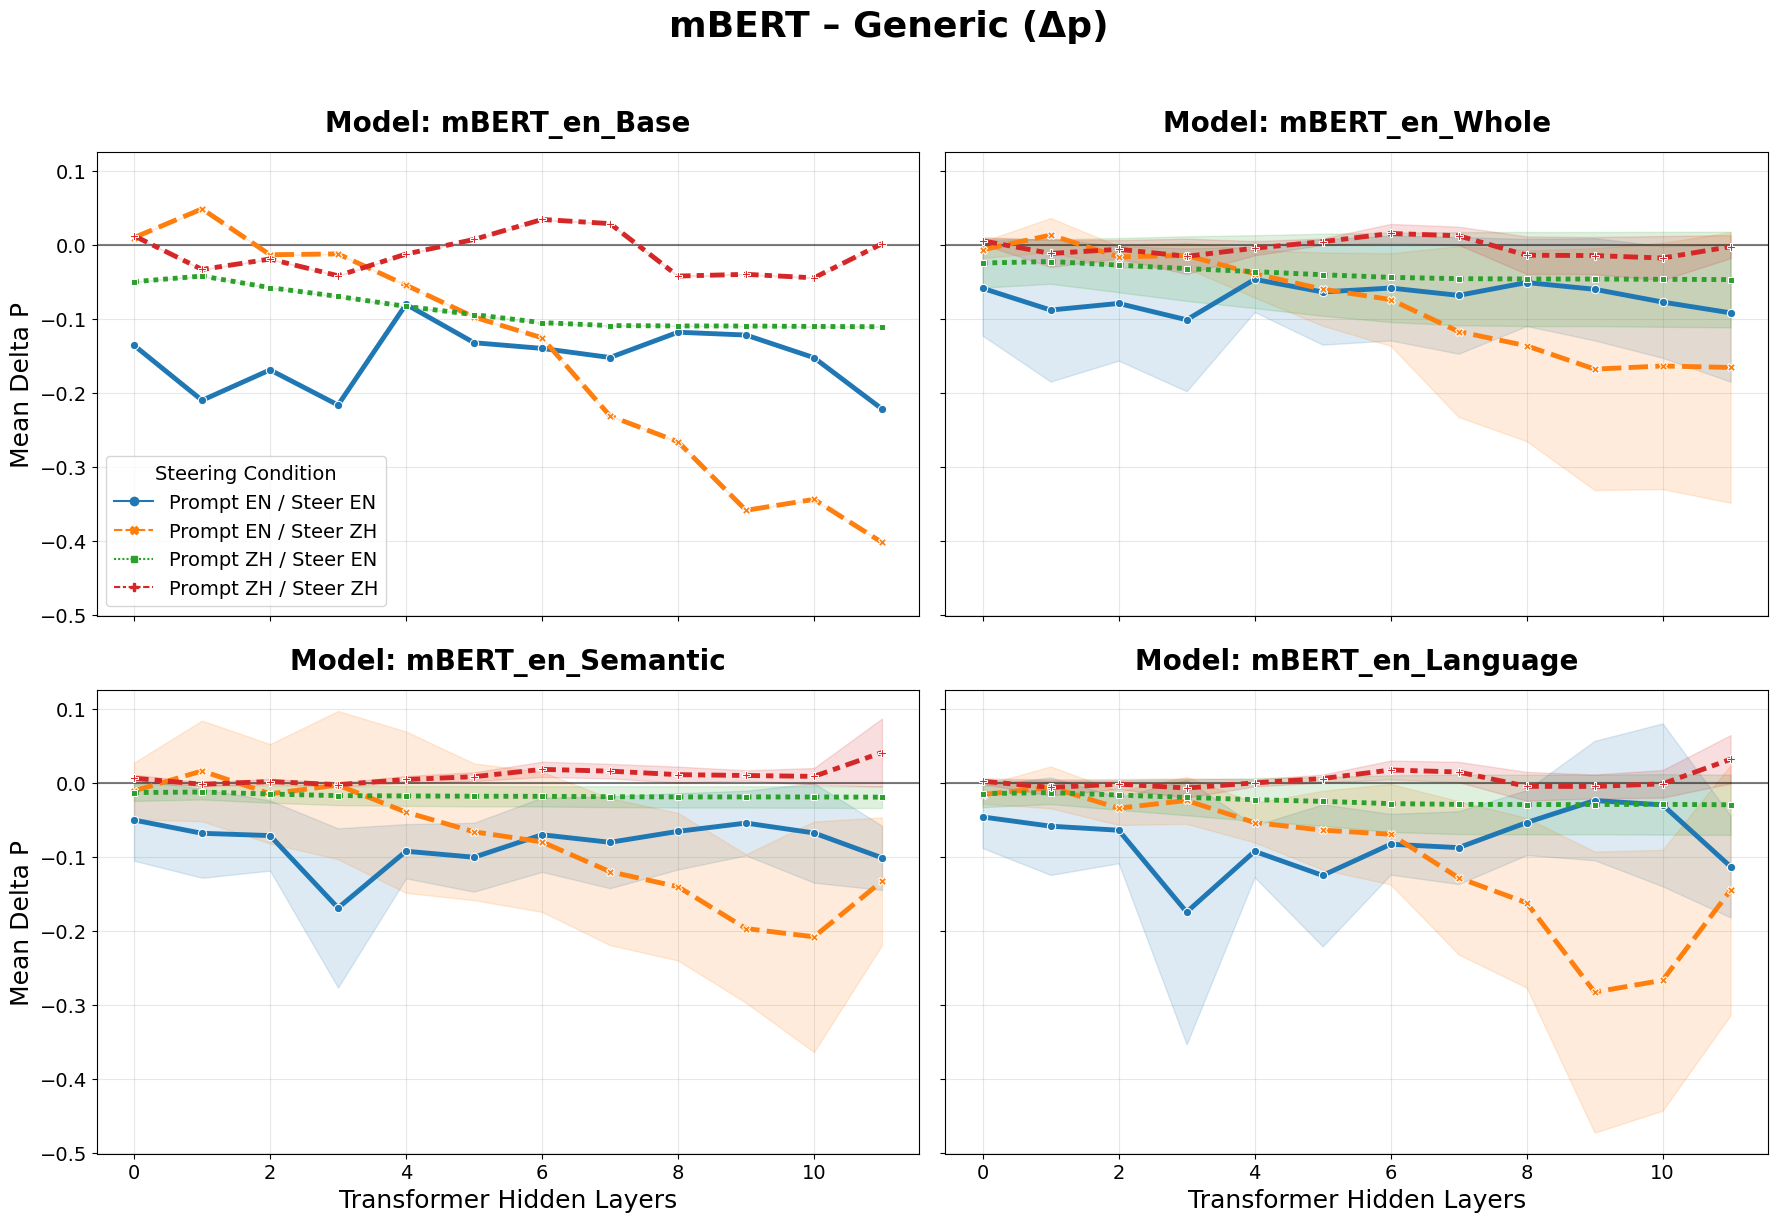

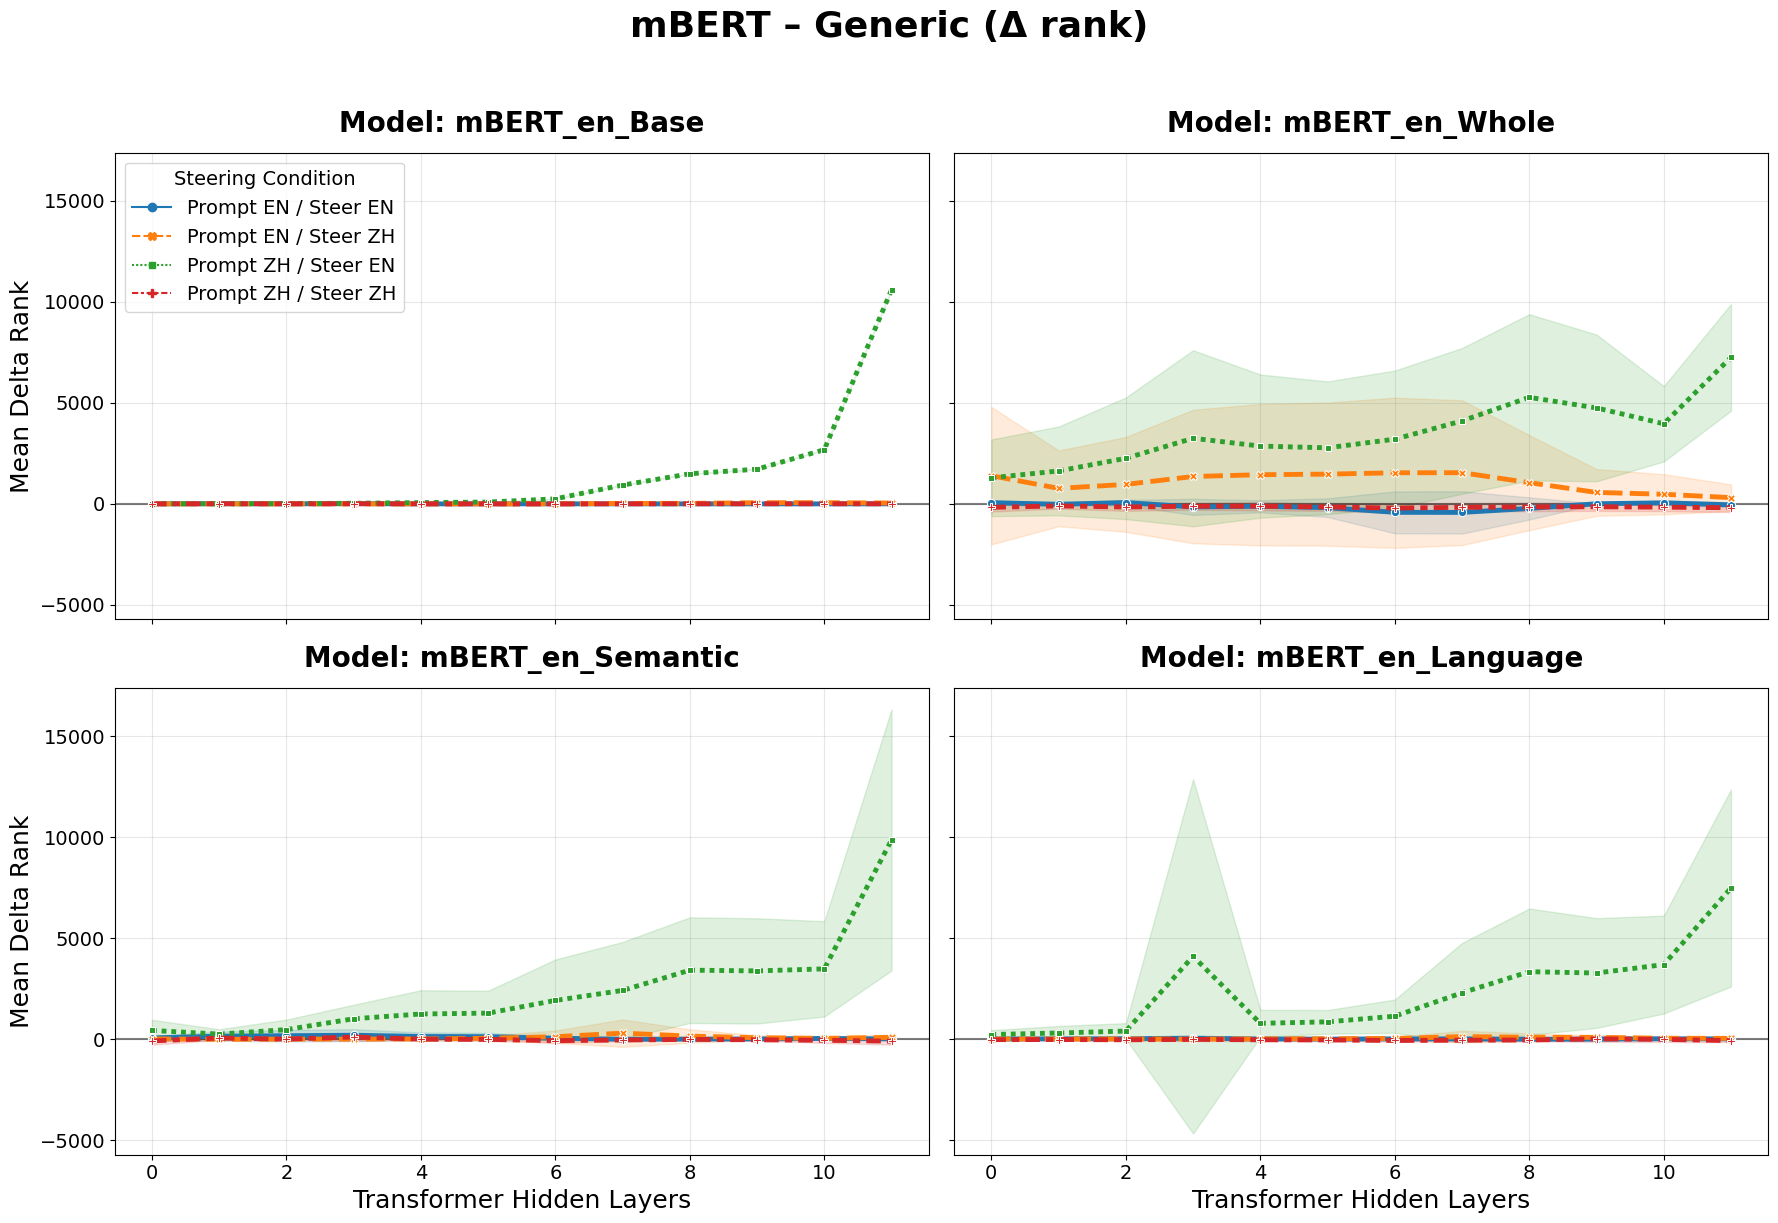

In [4]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      4     -0.080540
    mBERT_en_Base          en         zh      1      0.048516
    mBERT_en_Base          zh         en      1     -0.042281
    mBERT_en_Base          zh         zh      6      0.034220
mBERT_en_Language          en         en      9     -0.023862
mBERT_en_Language          en         zh      1     -0.006105
mBERT_en_Language          zh         en      1     -0.013087
mBERT_en_Language          zh         zh     11      0.031944
mBERT_en_Semantic          en         en      0     -0.050216
mBERT_en_Semantic          en         zh      1      0.016170
mBERT_en_Semantic          zh         en      1     -0.012316
mBERT_en_Semantic          zh         zh     11      0.041089
   mBERT_en_Whole          en         en      4     -0.046780
   mBERT_en_Whole          en         zh      1      0.013117
   m

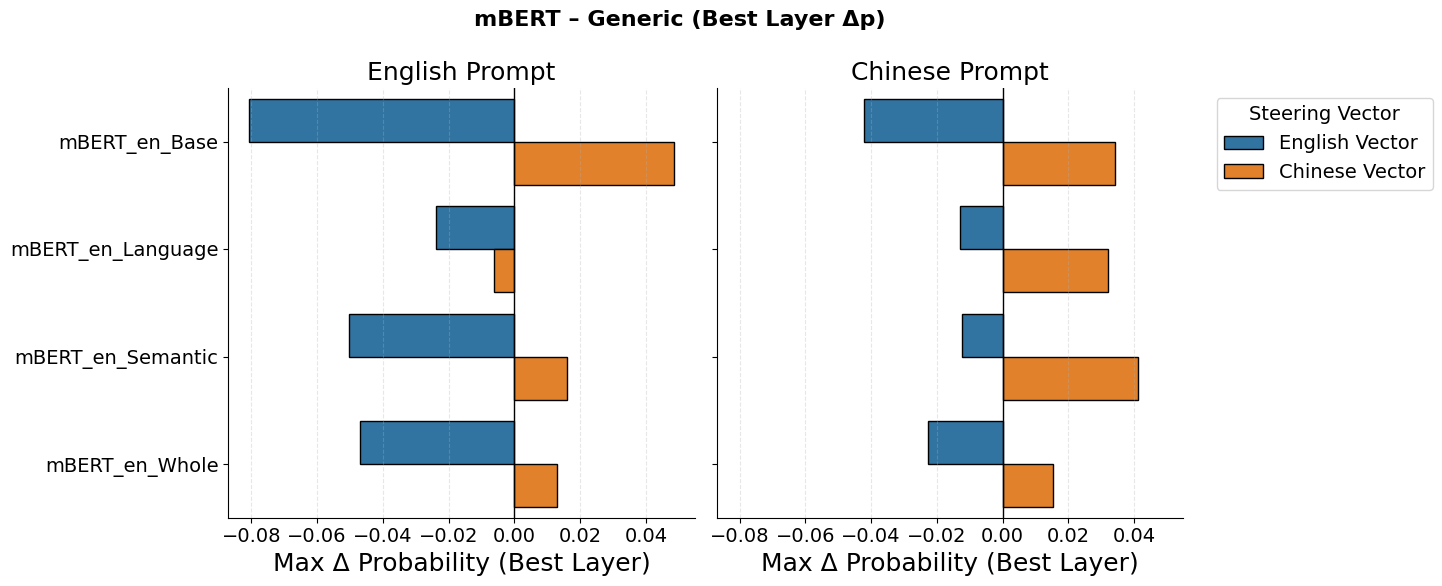

In [5]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     10         0.420290
    mBERT_en_Base          en         zh      1        -0.014493
    mBERT_en_Base          zh         en      1         5.855072
    mBERT_en_Base          zh         zh      6        -0.449275
mBERT_en_Language          en         en      8        -0.251208
mBERT_en_Language          en         zh      3         5.169082
mBERT_en_Language          zh         en      0       230.765700
mBERT_en_Language          zh         zh     11       -72.557971
mBERT_en_Semantic          en         en      7        -2.980676
mBERT_en_Semantic          en         zh      1       -10.466184
mBERT_en_Semantic          zh         en      1       253.043478
mBERT_en_Semantic          zh         zh     11       -98.671498
   mBERT_en_Whole          en         en      7      -421.929952
   mBERT_en_Whole       

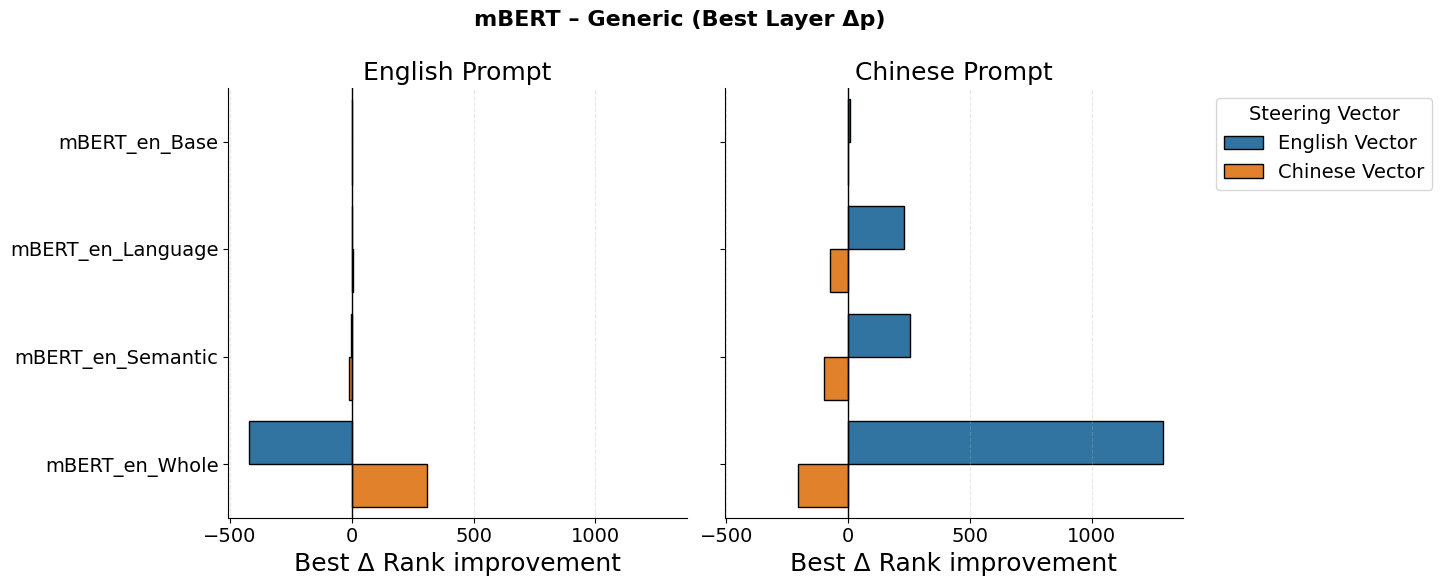

In [6]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT_zh 

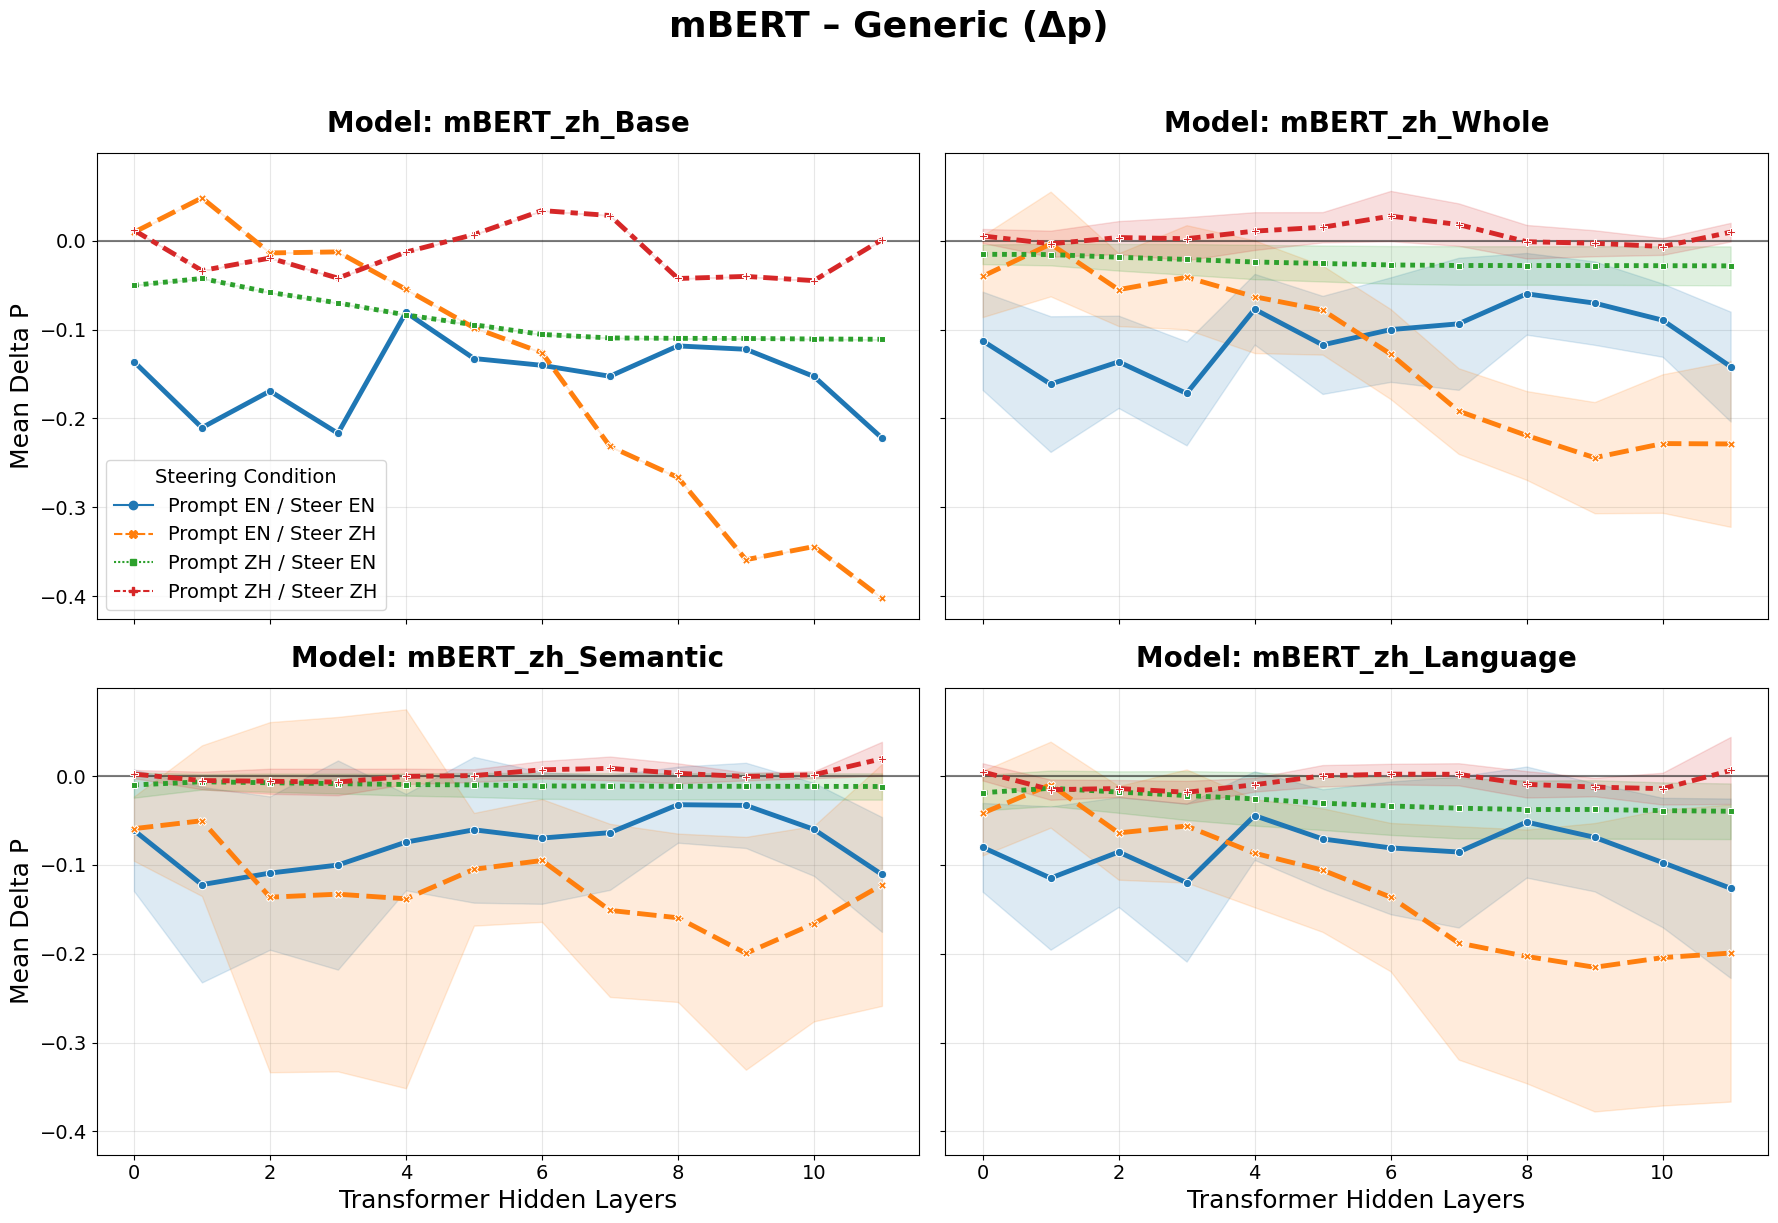

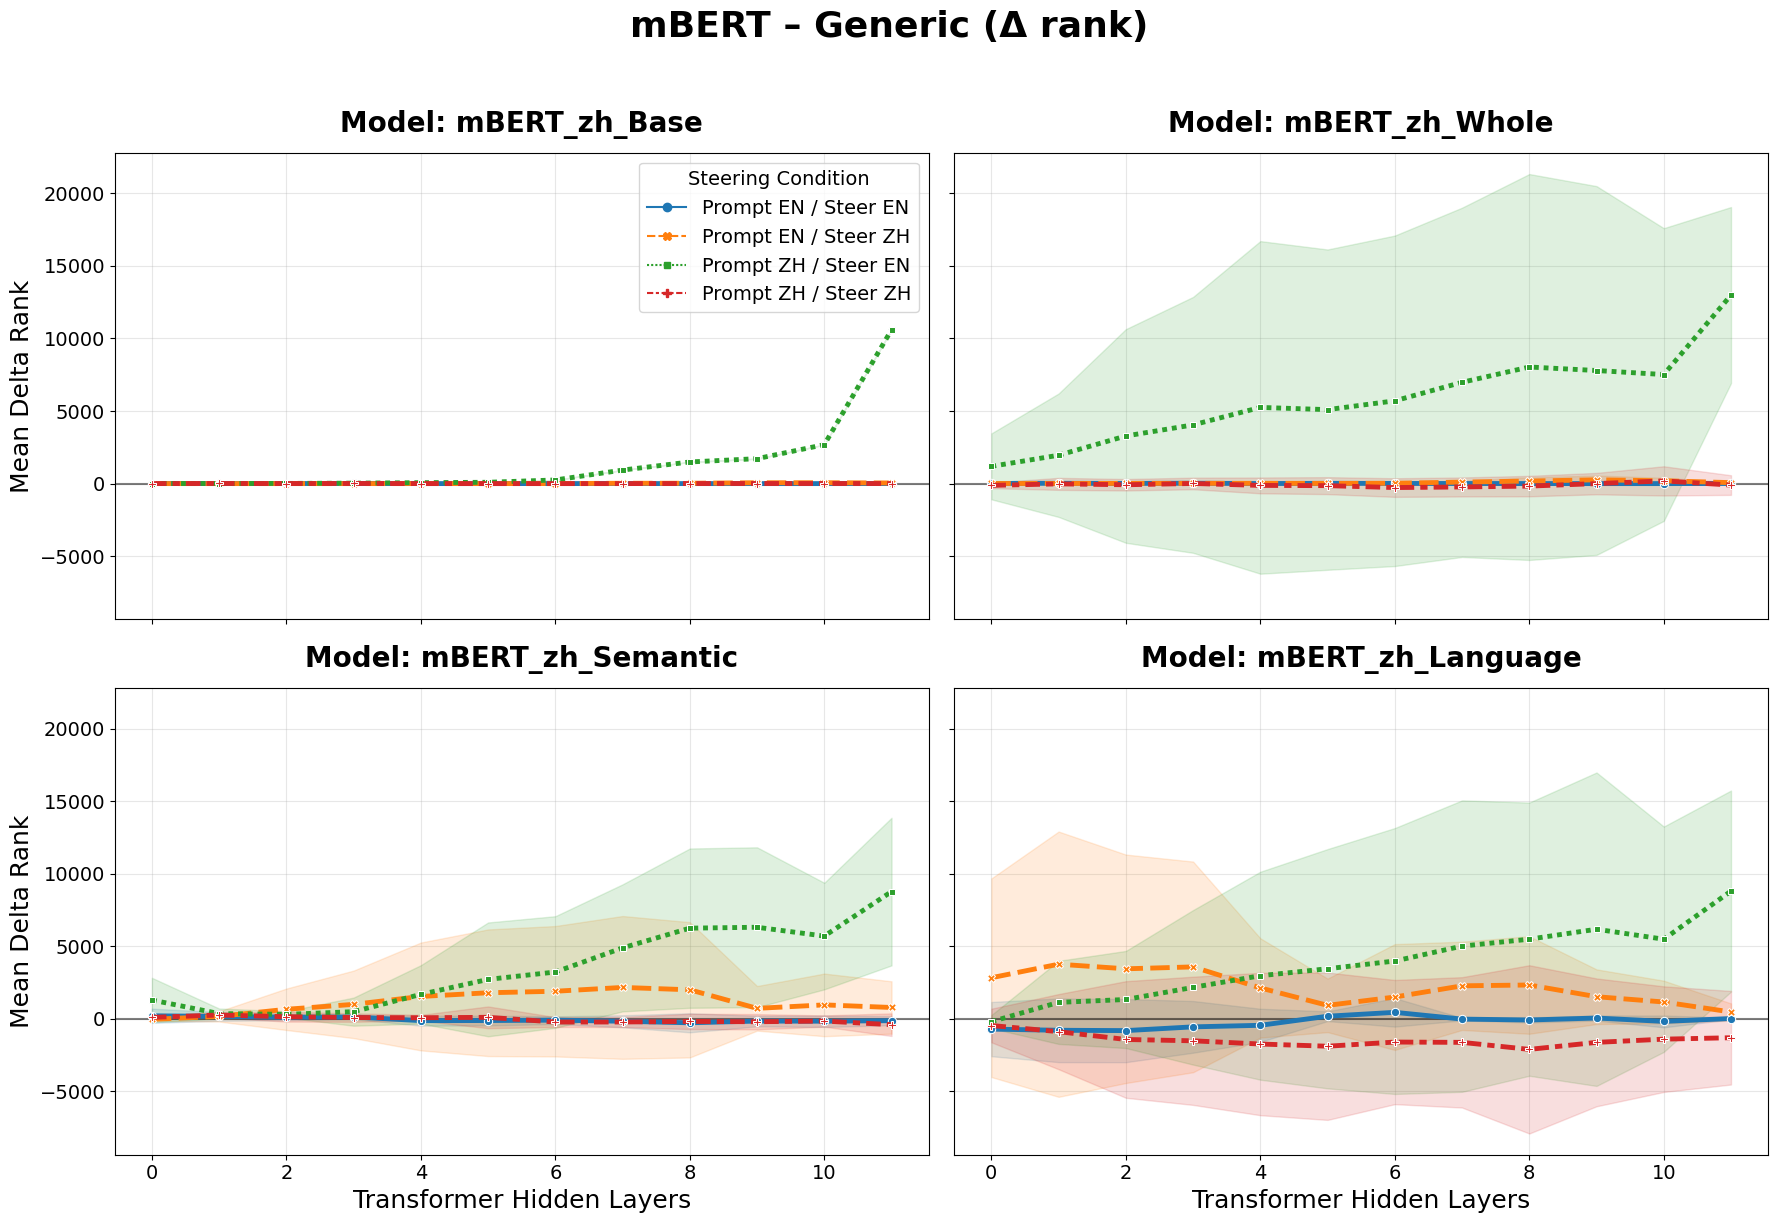

In [7]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      4     -0.080540
    mBERT_zh_Base          en         zh      1      0.048516
    mBERT_zh_Base          zh         en      1     -0.042281
    mBERT_zh_Base          zh         zh      6      0.034220
mBERT_zh_Language          en         en      4     -0.044378
mBERT_zh_Language          en         zh      1     -0.009514
mBERT_zh_Language          zh         en      1     -0.013572
mBERT_zh_Language          zh         zh     11      0.006510
mBERT_zh_Semantic          en         en      8     -0.032070
mBERT_zh_Semantic          en         zh      1     -0.050106
mBERT_zh_Semantic          zh         en      1     -0.006261
mBERT_zh_Semantic          zh         zh     11      0.019693
   mBERT_zh_Whole          en         en      8     -0.059583
   mBERT_zh_Whole          en         zh      1     -0.003468
   m

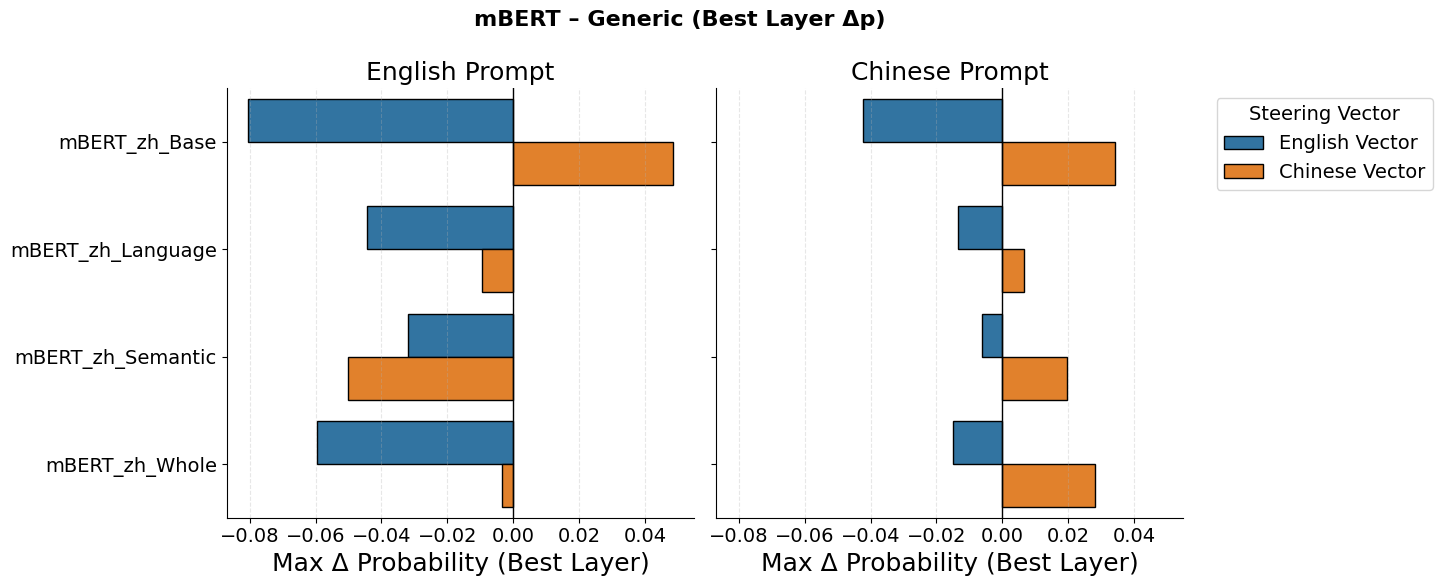

In [8]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     10         0.420290
    mBERT_zh_Base          en         zh      1        -0.014493
    mBERT_zh_Base          zh         en      1         5.855072
    mBERT_zh_Base          zh         zh      6        -0.449275
mBERT_zh_Language          en         en      2      -806.671498
mBERT_zh_Language          en         zh     11       474.898551
mBERT_zh_Language          zh         en      0      -190.618357
mBERT_zh_Language          zh         zh      8     -2099.818841
mBERT_zh_Semantic          en         en      8      -268.086957
mBERT_zh_Semantic          en         zh      0       -27.067633
mBERT_zh_Semantic          zh         en      2       309.777778
mBERT_zh_Semantic          zh         zh     11      -399.004831
   mBERT_zh_Whole          en         en      9        -0.016908
   mBERT_zh_Whole       

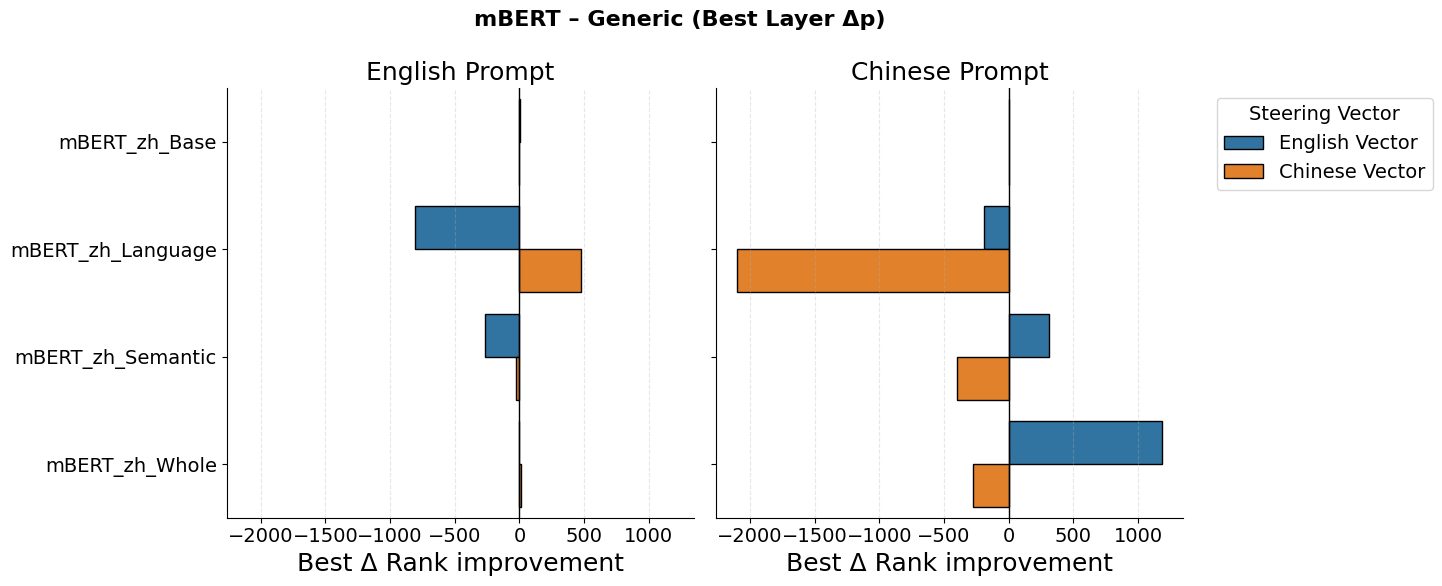

In [9]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

# Targeted Prompts

In [10]:
family = "mBERT"
target = "Generic"

full_by_subj, summary_by_subj = viz.load_cloze_steering_results(
    subjects=subjects,
    family_name=family,
    target=target,
    base_dir="steering_vectors",
)


avg_summary = viz.make_average_cloze_summary(
    summary_by_subject=summary_by_subj,
    average_key=f"{family}_{target}_avg",
)

[Cloze] Loaded mBERT cloze results for subject COL
[Cloze] Loaded mBERT cloze results for subject GFW
[Cloze] Loaded mBERT cloze results for subject JUS
[Cloze] Loaded mBERT cloze results for subject KOP
[Cloze] Loaded mBERT cloze results for subject TYE
[Cloze] Loaded mBERT cloze results for subject ZEK


## mBERT_en 

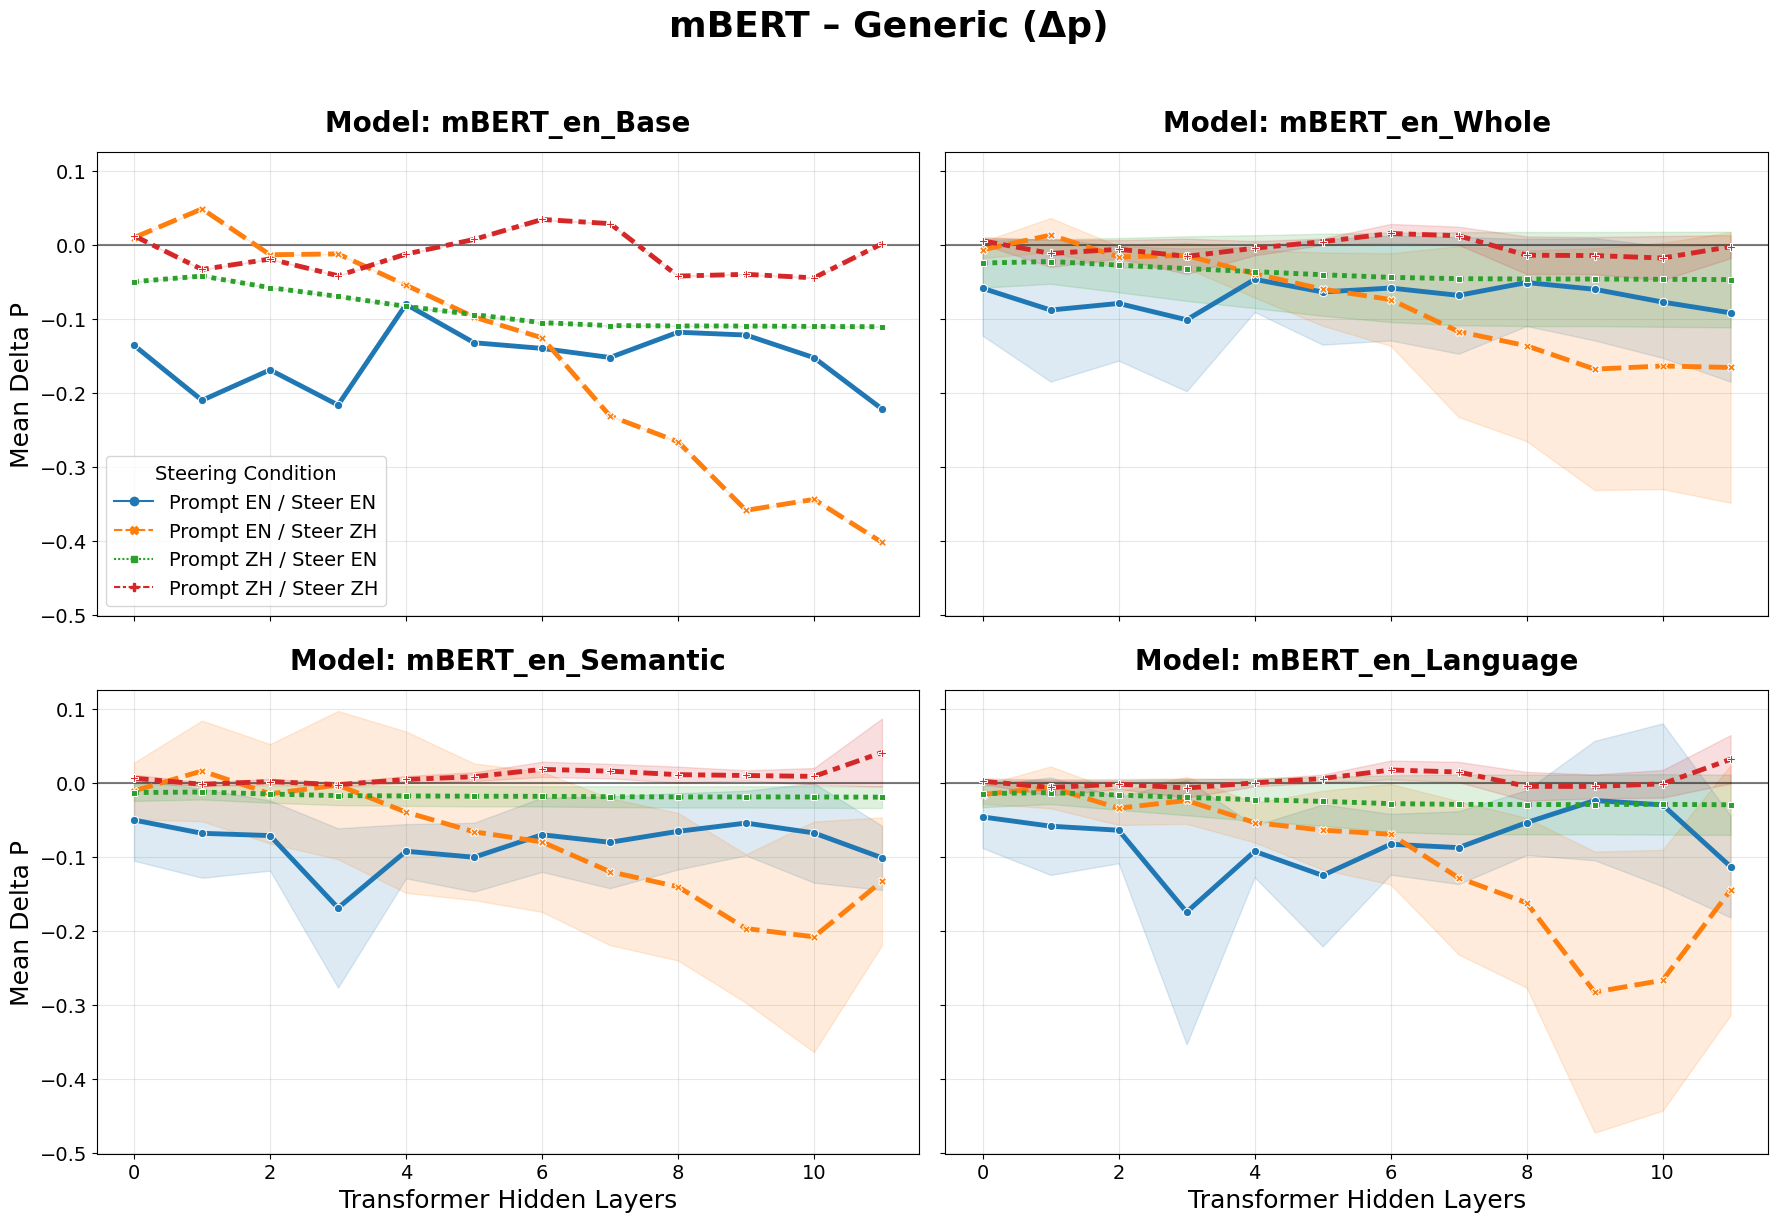

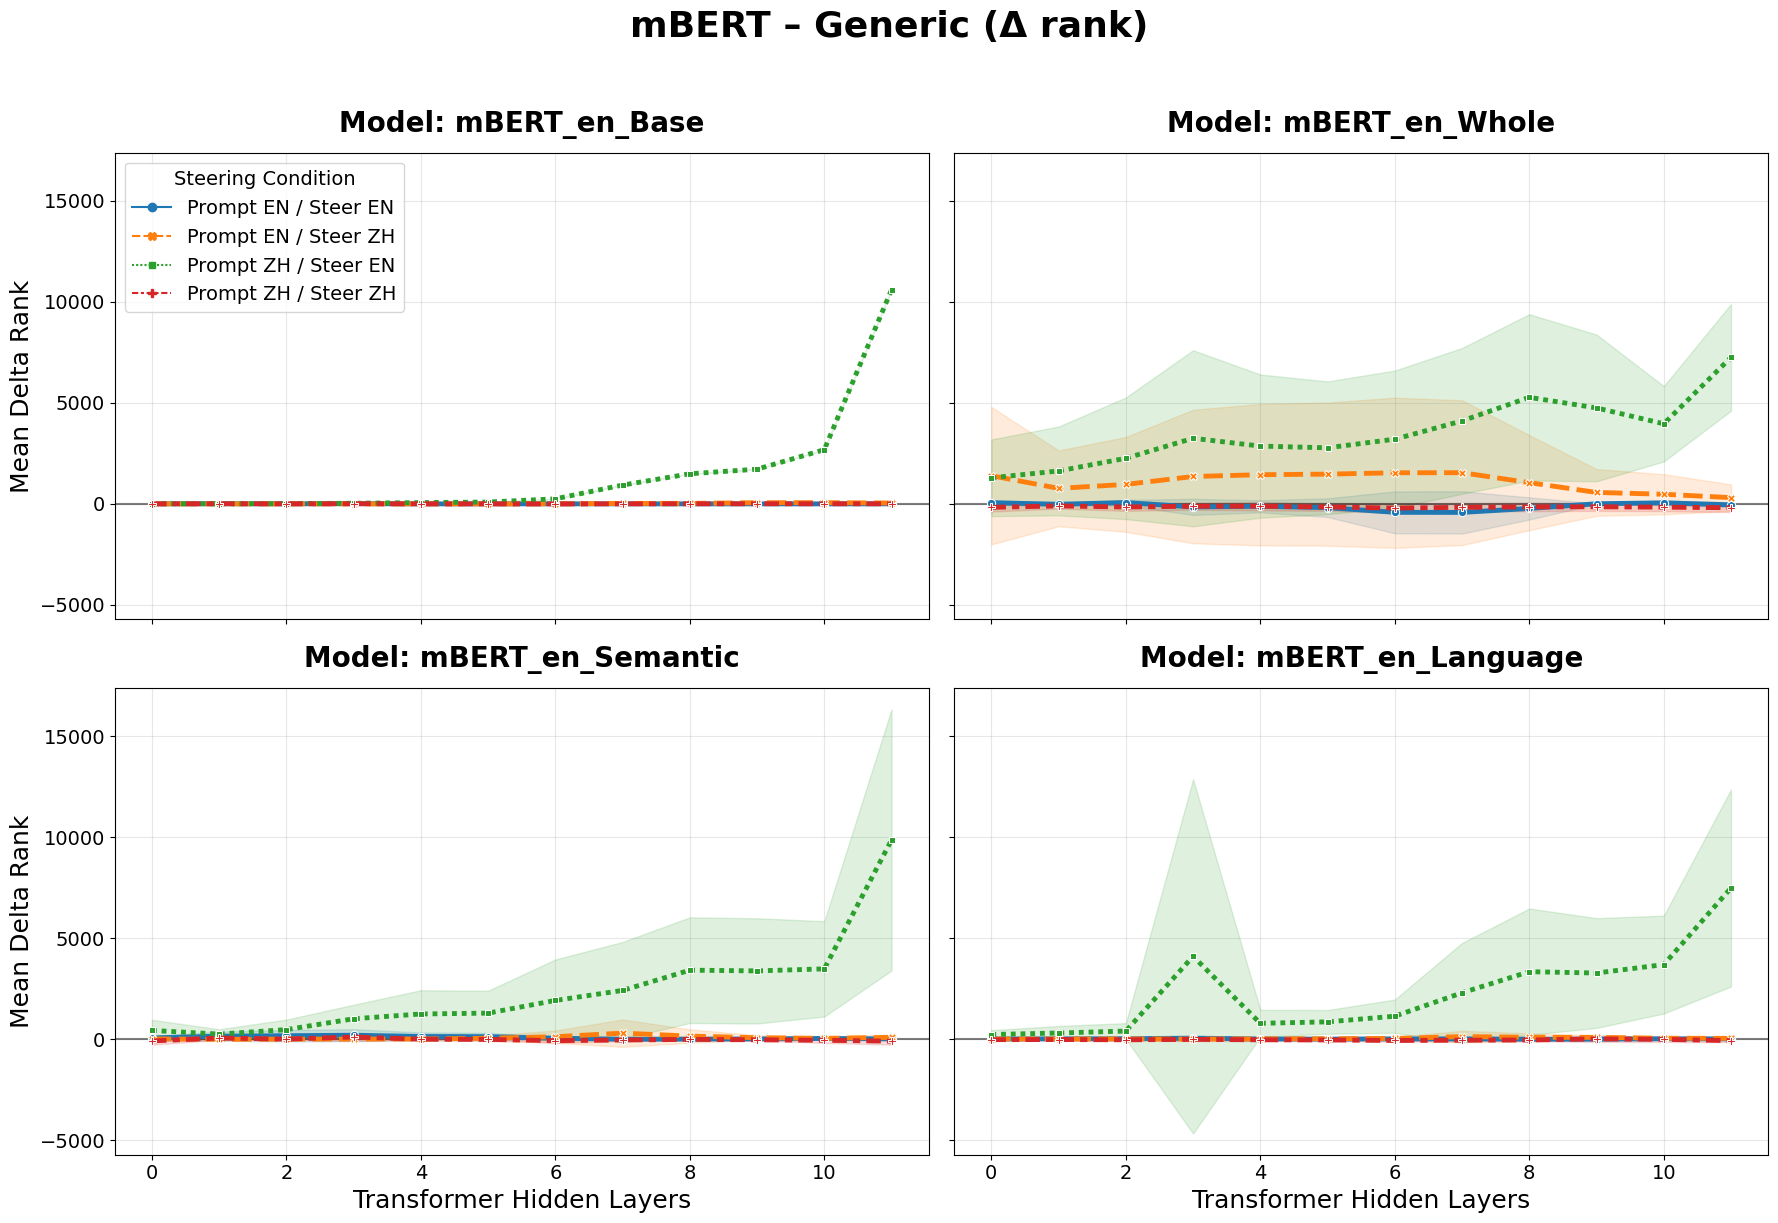

In [11]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-en",
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_en_Base          en         en      4     -0.080540
    mBERT_en_Base          en         zh      1      0.048516
    mBERT_en_Base          zh         en      1     -0.042281
    mBERT_en_Base          zh         zh      6      0.034220
mBERT_en_Language          en         en      9     -0.023862
mBERT_en_Language          en         zh      1     -0.006105
mBERT_en_Language          zh         en      1     -0.013087
mBERT_en_Language          zh         zh     11      0.031944
mBERT_en_Semantic          en         en      0     -0.050216
mBERT_en_Semantic          en         zh      1      0.016170
mBERT_en_Semantic          zh         en      1     -0.012316
mBERT_en_Semantic          zh         zh     11      0.041089
   mBERT_en_Whole          en         en      4     -0.046780
   mBERT_en_Whole          en         zh      1      0.013117
   m

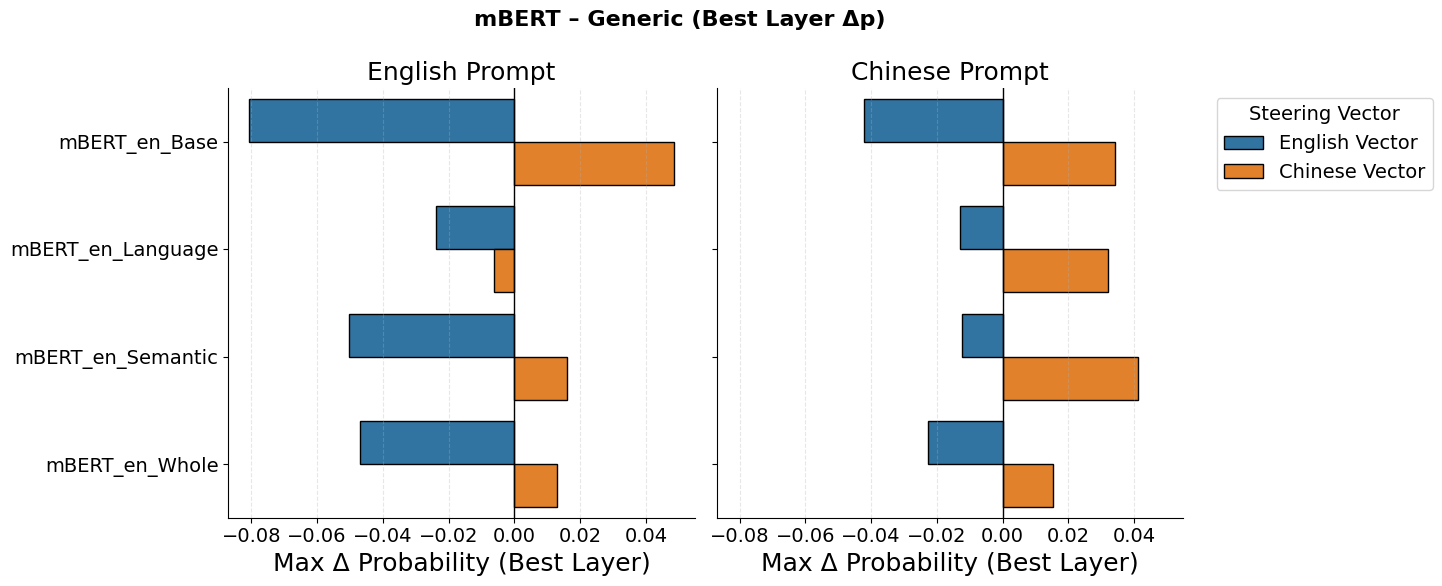

In [12]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_en_Base          en         en     10         0.420290
    mBERT_en_Base          en         zh      1        -0.014493
    mBERT_en_Base          zh         en      1         5.855072
    mBERT_en_Base          zh         zh      6        -0.449275
mBERT_en_Language          en         en      8        -0.251208
mBERT_en_Language          en         zh      3         5.169082
mBERT_en_Language          zh         en      0       230.765700
mBERT_en_Language          zh         zh     11       -72.557971
mBERT_en_Semantic          en         en      7        -2.980676
mBERT_en_Semantic          en         zh      1       -10.466184
mBERT_en_Semantic          zh         en      1       253.043478
mBERT_en_Semantic          zh         zh     11       -98.671498
   mBERT_en_Whole          en         en      7      -421.929952
   mBERT_en_Whole       

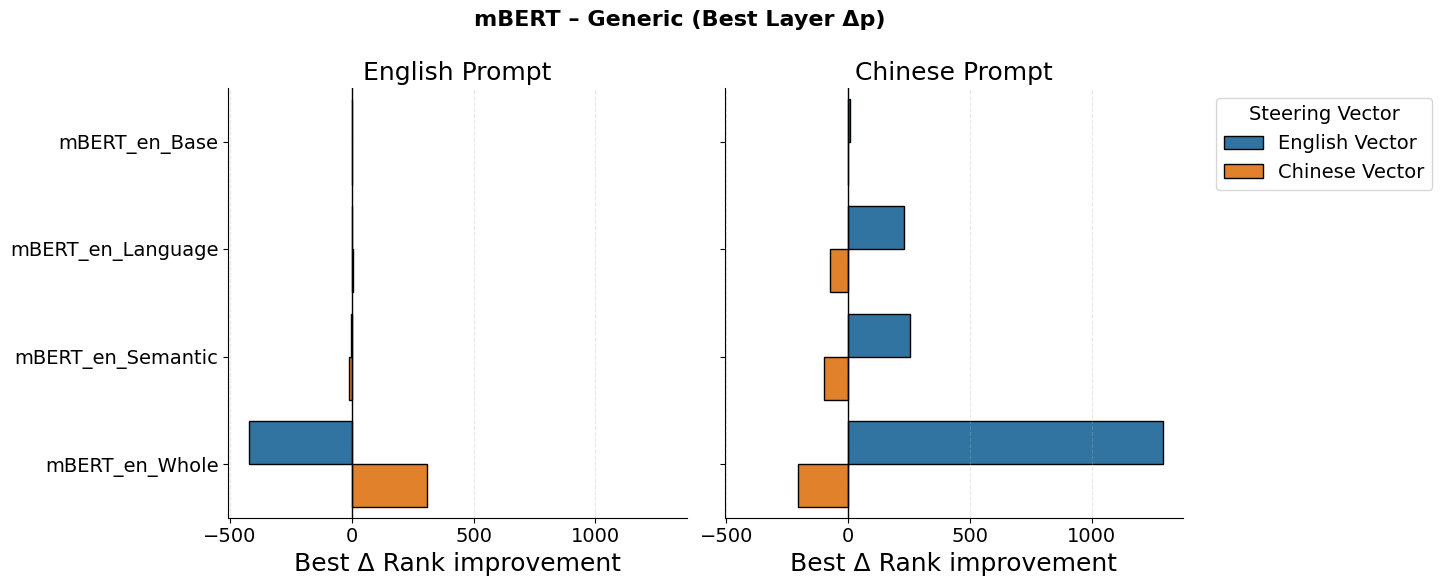

In [13]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_en,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);

## mBERT-zh

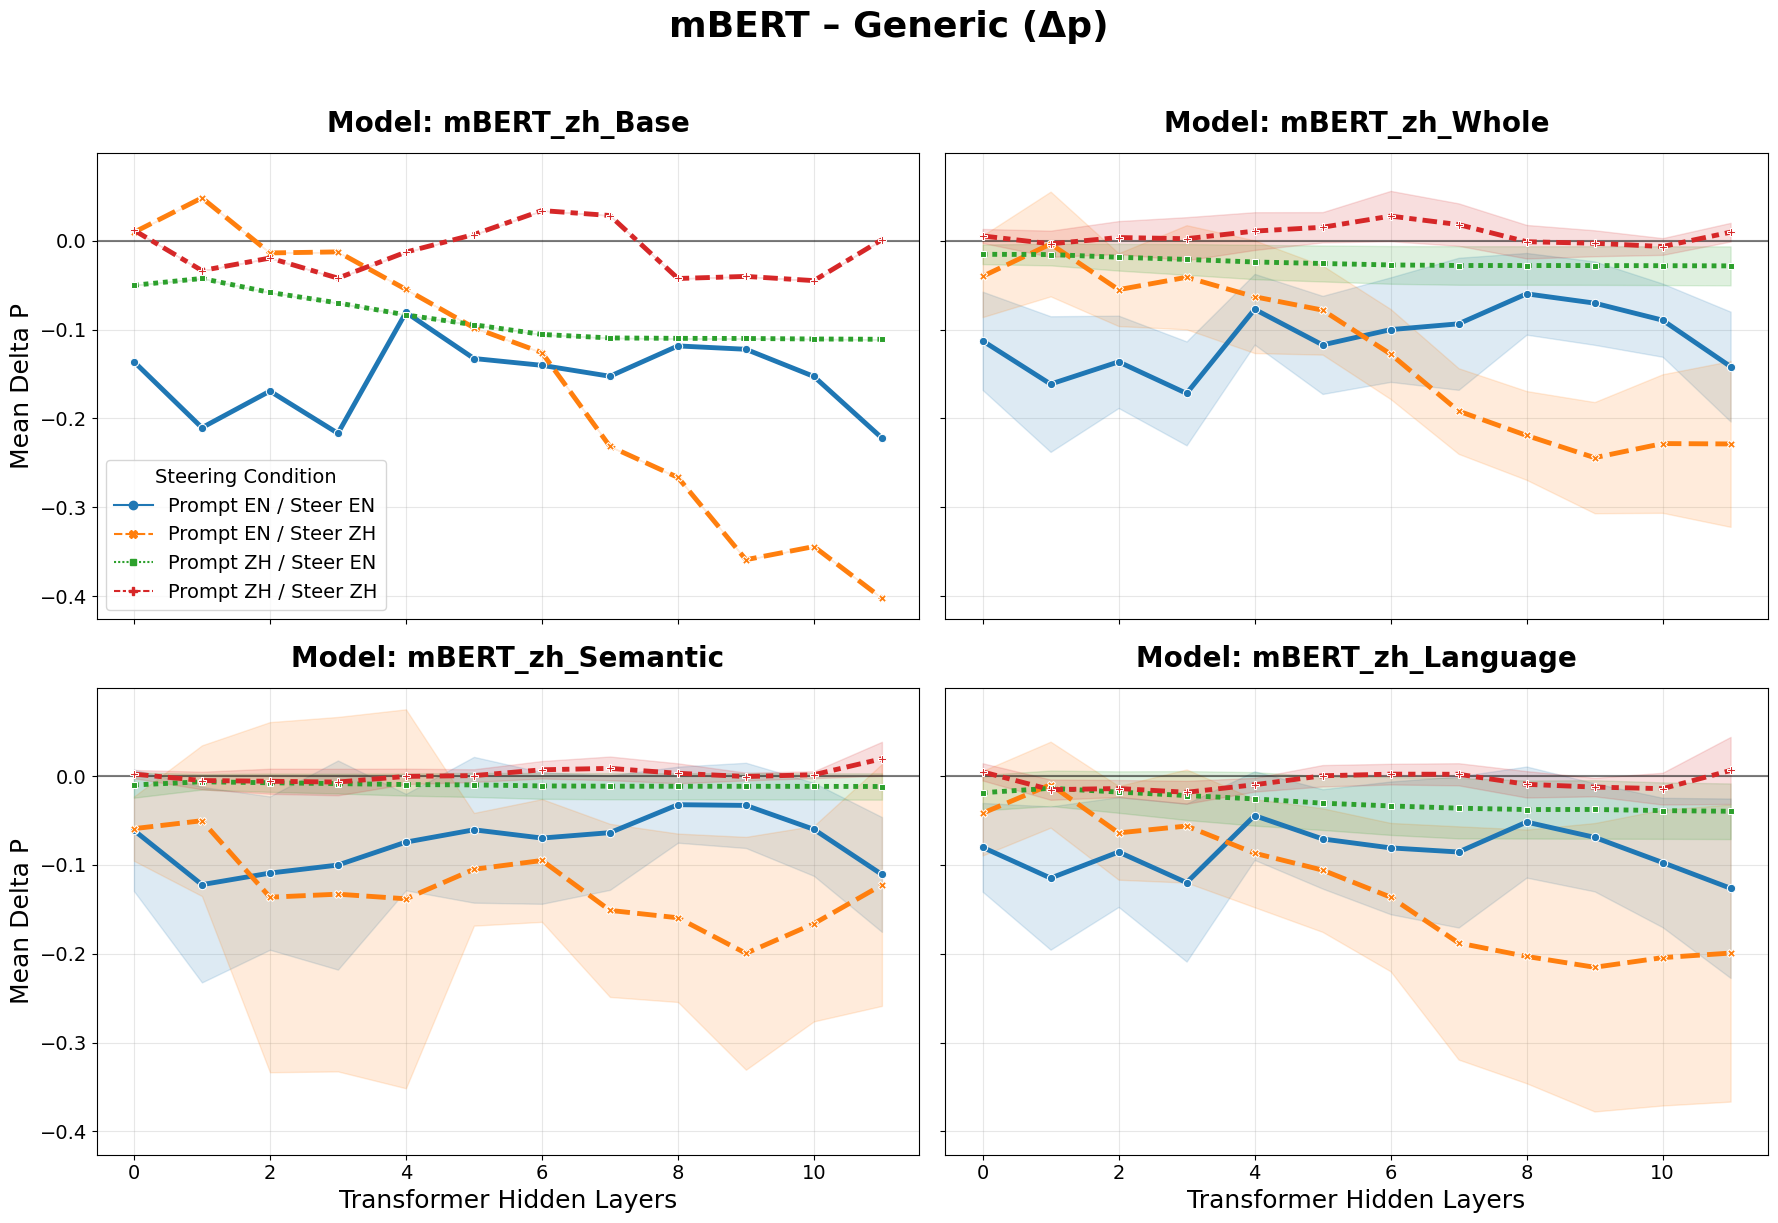

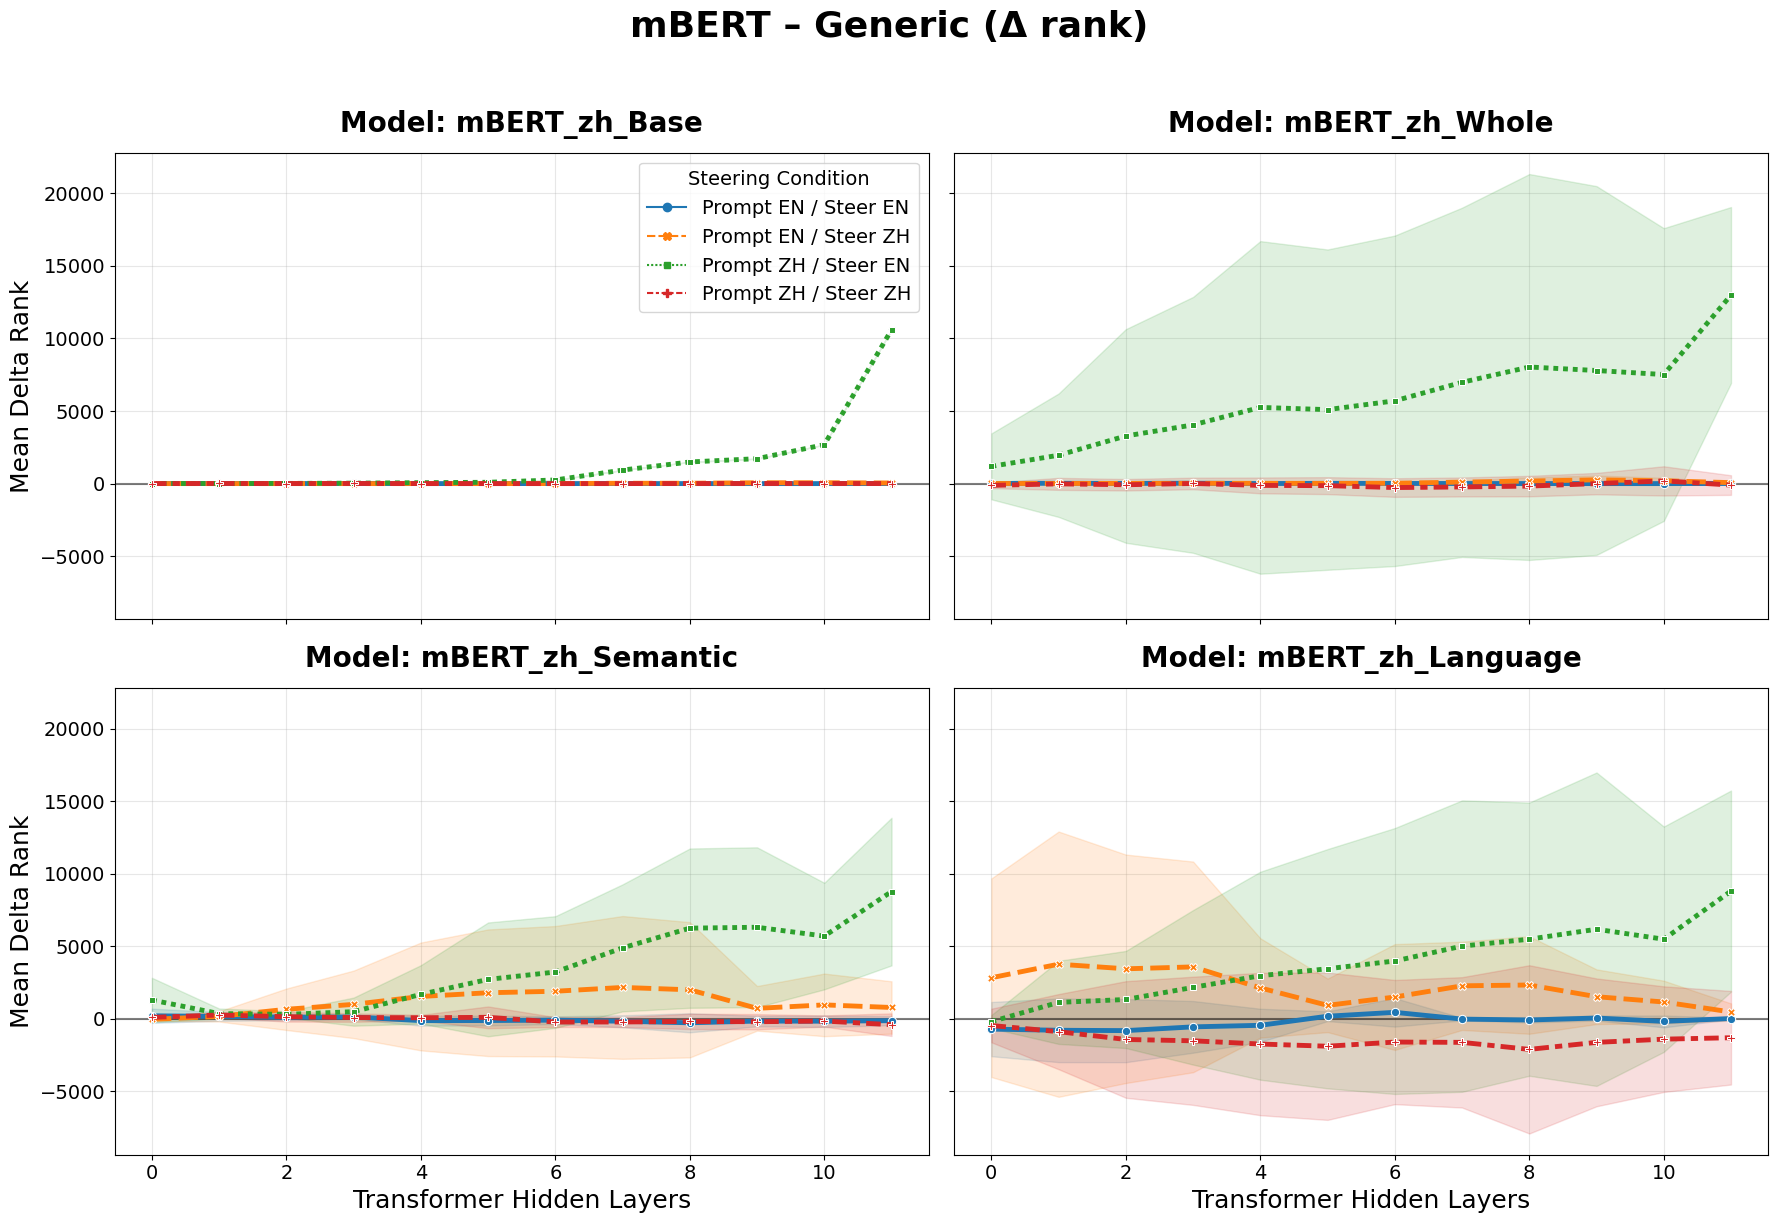

In [14]:
viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Δp)",
)

viz.plot_layerwise_mechanism_grid(
    summary_df=avg_summary,
    model_family_name="mBERT-zh",
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Δ rank)",  
)


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_p
    mBERT_zh_Base          en         en      4     -0.080540
    mBERT_zh_Base          en         zh      1      0.048516
    mBERT_zh_Base          zh         en      1     -0.042281
    mBERT_zh_Base          zh         zh      6      0.034220
mBERT_zh_Language          en         en      4     -0.044378
mBERT_zh_Language          en         zh      1     -0.009514
mBERT_zh_Language          zh         en      1     -0.013572
mBERT_zh_Language          zh         zh     11      0.006510
mBERT_zh_Semantic          en         en      8     -0.032070
mBERT_zh_Semantic          en         zh      1     -0.050106
mBERT_zh_Semantic          zh         en      1     -0.006261
mBERT_zh_Semantic          zh         zh     11      0.019693
   mBERT_zh_Whole          en         en      8     -0.059583
   mBERT_zh_Whole          en         zh      1     -0.003468
   m

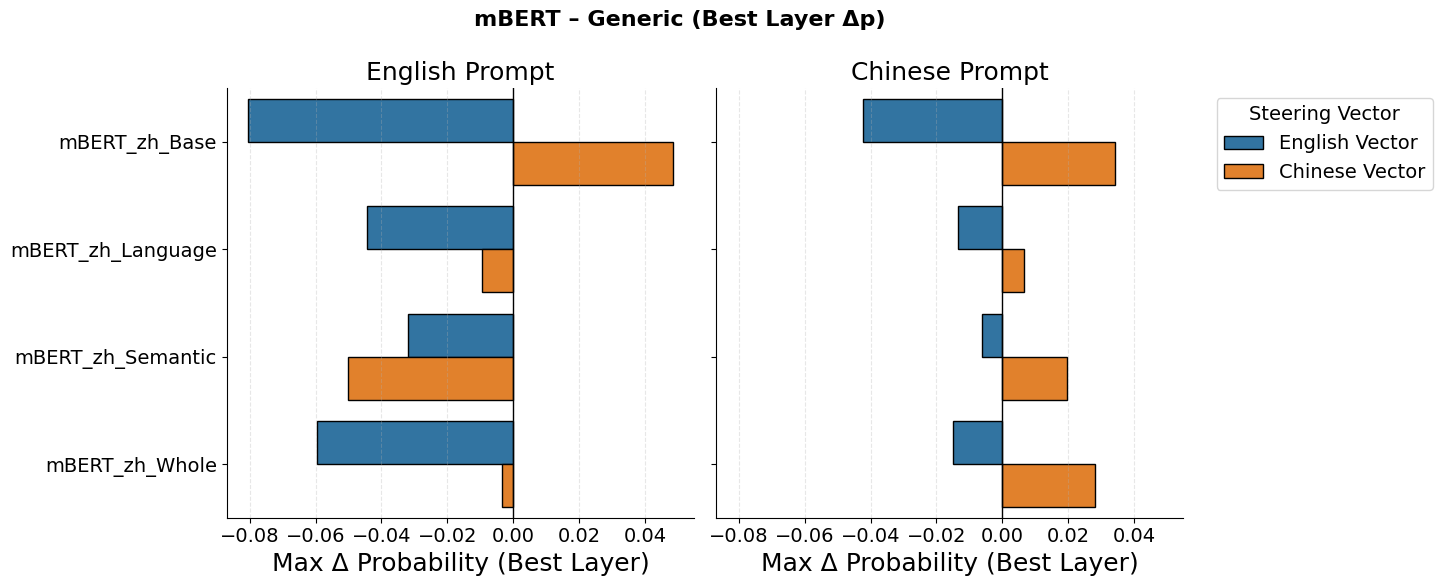

In [15]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_p",
    title=f"{family} – {target} (Best Layer Δp)",
);


--- Best Layers Selected for mBERT – Generic (Best Layer Δp) ---
            model prompt_lang steer_lang  layer  mean_delta_rank
    mBERT_zh_Base          en         en     10         0.420290
    mBERT_zh_Base          en         zh      1        -0.014493
    mBERT_zh_Base          zh         en      1         5.855072
    mBERT_zh_Base          zh         zh      6        -0.449275
mBERT_zh_Language          en         en      2      -806.671498
mBERT_zh_Language          en         zh     11       474.898551
mBERT_zh_Language          zh         en      0      -190.618357
mBERT_zh_Language          zh         zh      8     -2099.818841
mBERT_zh_Semantic          en         en      8      -268.086957
mBERT_zh_Semantic          en         zh      0       -27.067633
mBERT_zh_Semantic          zh         en      2       309.777778
mBERT_zh_Semantic          zh         zh     11      -399.004831
   mBERT_zh_Whole          en         en      9        -0.016908
   mBERT_zh_Whole       

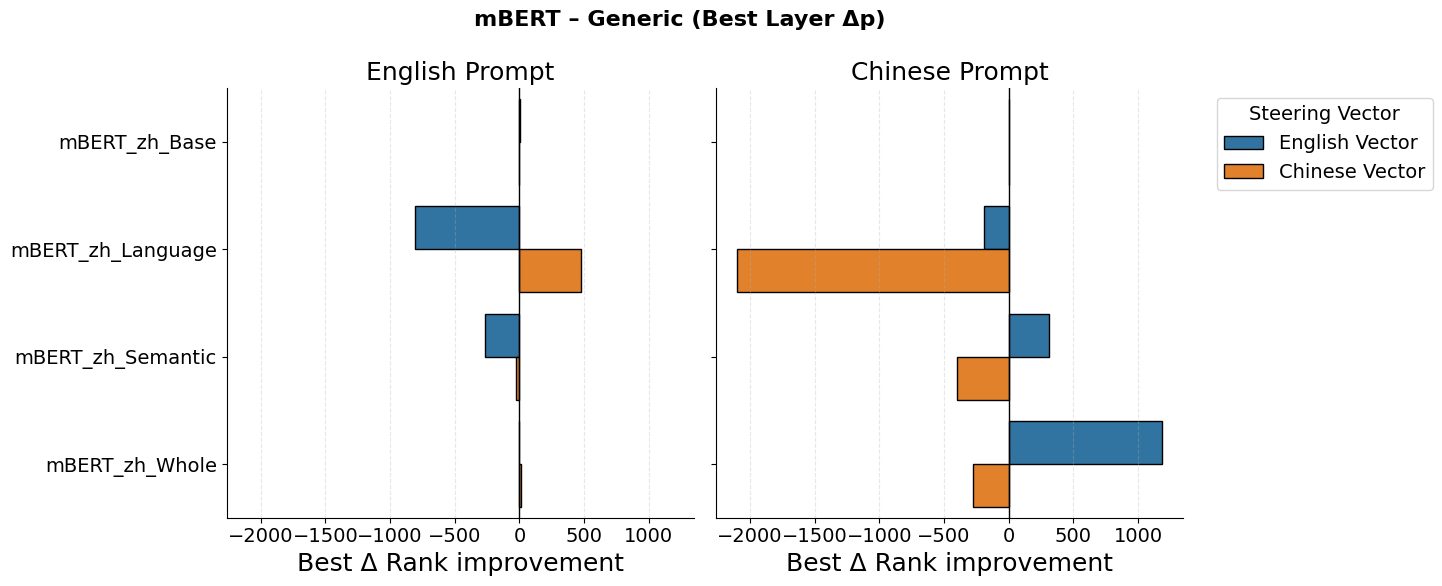

In [16]:
viz.plot_best_layer_bar(
    summary_df=avg_summary,
    model_names=model_names_zh,
    metric="mean_delta_rank",
    title=f"{family} – {target} (Best Layer Δp)",
);